In [1]:
import gurobipy as grb
import numpy as np
import timeit
import scipy
from sklearn.datasets import make_classification
import sklearn
from ucimlrepo import fetch_ucirepo 
import math
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
import copy
from sklearn.utils import shuffle
from sklearn.preprocessing import OneHotEncoder
from collections import Counter
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, normalize


In [2]:
def generate_n_sample_vec(y_all, perc_test):
    unique_classes, class_counts = np.unique(y_all, return_counts=True)

    # Compute number of test samples per class
    n_sample = np.floor(class_counts * perc_test).astype(int)

    # Ensure at least 1 test sample for each class if it has more than 0 samples
    for i, count in enumerate(class_counts):
        if n_sample[i] == 0 and count > 0:
            n_sample[i] = 1

    # Compute training samples per class
    n_train_rem = class_counts - n_sample

    # Create dictionaries for train and test samples per class
    n_train = {unique_classes[i]: n_train_rem[i] for i in range(len(unique_classes))}
    n_test = {unique_classes[i]: n_sample[i] for i in range(len(unique_classes))}

    print(f" n_train: {n_train}, n_test: {n_test}")
    return n_train, n_test

def class_split_per_client(train_class_counts, perc_class_per_client, G, client_sample_props):
    
    n_classes = len(train_class_counts)
    
    if isinstance(perc_class_per_client, np.ndarray):
        print("Using user-defined percentages")
        if perc_class_per_client.shape != (G, n_classes):
            raise ValueError(f"The shape of `perc_class_per_client` should be ({G}, {n_classes})")

        row_sums = perc_class_per_client.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # Prevent division by zero
        perc_class_per_client = perc_class_per_client / row_sums
        
        use_client_sample_props = True
        if client_sample_props is None:
            client_sample_props = [1 / G] * G
        
    elif perc_class_per_client == -1:
        
        if G == 1:
            perc_class_per_client = {0: {class_label: 1.0 for class_label in train_class_counts}}  # Single client gets all
        
        else:
            
            if G == 2:
                perc_class_per_client = {}
                for class_label in train_class_counts:
                    r = np.random.uniform(low=0.1, high=0.9)
                    perc_class_per_client[0] = perc_class_per_client.get(0, {})
                    perc_class_per_client[0][class_label] = r
                    perc_class_per_client[1] = perc_class_per_client.get(1, {})
                    perc_class_per_client[1][class_label] = 1 - r
                
            else:
                
                perc_class_per_client = {g: {class_label: 0 for class_label in train_class_counts.keys()} for g in range(G)}
                for class_label in train_class_counts:
                    remaining = 1.0
                    for g in range(G - 1):
                        min_allowed = 0.1
                        max_allowed = remaining - min_allowed * (G - g - 1)
                        r = np.random.uniform(low=min_allowed, high=max_allowed)
                        perc_class_per_client[g] = perc_class_per_client.get(g, {})
                        perc_class_per_client[g][class_label] = r
                        remaining -= r
                    perc_class_per_client[G - 1][class_label] = remaining
                    
    
    elif perc_class_per_client == 0:
        perc_class_per_client = {g: {class_label: 1/G for class_label in train_class_counts} for g in range(G)}
        
        
        use_client_sample_props = False
    else:
        use_client_sample_props = True
        
    print(f"Per class per client:{perc_class_per_client}")
    
    
    class_split = {g: {} for g in range(G)}  

    for class_label, total_available in train_class_counts.items():  
        print(f"Class {class_label}: Total available samples: {total_available}")
        
        
        if use_client_sample_props and client_sample_props is not None:
            allocations = [
                int(np.floor(
                    total_available *
                    client_sample_props[g] *
                    perc_class_per_client[g].get(class_label, 0)
                ))
                for g in range(G)
            ]
        else:
            allocations = [
                int(np.floor(
                    total_available *
                    perc_class_per_client[g].get(class_label, 0)
                ))
                for g in range(G)
            ]
        
        total_allocated = sum(allocations)
        discrepancy = total_available - total_allocated
        
        print(f"Class {class_label}: Preliminary allocations: {allocations}")
        print(f"Class {class_label}: Total allocated after floor: {total_allocated}")
        print(f"Class {class_label}: Discrepancy: {discrepancy}")
        
        
        for g in range(G):
            if discrepancy > 0:
                allocations[g] += 1  
                discrepancy -= 1  
                

        if total_available < G:
    
            for g in range(total_available):  
                allocations[g] = 1 

            for g in range(total_available, G):
                allocations[g] = 0  
                
        print(f"Class {class_label}: Final allocations per client: {allocations}")   
        
        for g in range(G):
            class_split[g][class_label] = allocations[g]
         
        
    print(f"Class Split:{class_split}")
        
    return class_split

def change_labels(perc_wrong_y, total_samples, num_classes, y):
    
    n_wrong = round(perc_wrong_y * total_samples)
    if n_wrong == 0:
        return y  

    idx_wrong = np.random.choice(total_samples, n_wrong, replace=False)

    for i in idx_wrong:
        old_label = y[i]
        possible_labels = [l for l in range(num_classes) if l != old_label]  
        y[i] = np.random.choice(possible_labels)  

    print(f"Flipped {n_wrong} labels out of {total_samples}")
    
    return y

In [3]:
class MultiFederatedDRSVM:
    def __init__(self, param, num_clients, num_classes, feature_dim):
        self.epsilon = param['epsilon']
        self.kappa = param['kappa']
        self.pnorm = param['pnorm']
        self.rho = param['rho']  
        self.tau = param['tau'] 
        self.num_clients = num_clients
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.alphag_vec = np.ones(self.num_clients)  
        self.Ng_vec = np.zeros(self.num_clients)
        
        self.local_models = [{} for _ in range(num_clients)]
        self.global_model = np.zeros((num_classes, self.feature_dim))  # Weight matrix M: Rows (Classes) * Columns (features)
        #List of mu matrices, one per client
        self.mu = [np.zeros((num_classes, self.feature_dim)) for _ in range(num_clients)] #ADMM dual for each client g: Rows (Classes) * Columns (features)
        
        
    def local_update(self, client_id, x_train, y_train, M_global, mu):

        row, col = x_train.shape
        optimal = {}
        
        encoder = OneHotEncoder(sparse=False)
        y_train_one_hot = encoder.fit_transform(y_train.reshape(-1, 1))
        
        
        # Step 0: Create model
        model = grb.Model(f'DRSVM_Client_{client_id}')
        model.setParam('OutputFlag', False)

        #Step 1: Define decision variables
        var_lambda = model.addVar(vtype=grb.GRB.CONTINUOUS, lb=0.0, name="lambda")
        var_s = var_s = {i: model.addVar(vtype=grb.GRB.CONTINUOUS, lb=0.0, name=f"s[{i}]") for i in range(row)} #Slack variable for each training sample
        
        #Decision variable (Matrix) that holds the weight for class c and feature j
        var_M = {(c, j): model.addVar(vtype=grb.GRB.CONTINUOUS, lb=-grb.GRB.INFINITY)
         for c in range(self.num_classes) for j in range(col)}
        
        # L1 norm constraint
        if self.pnorm == 1:
            slack_var = {(i, j, p): model.addVar(vtype=grb.GRB.CONTINUOUS)
                         for i in range(self.num_classes) 
                         for j in range(self.num_classes) 
                         for p in range(col)}

            
        #Step 2: Integrate variables
        model.update()
        
        #Step 3: Define constraints
        for i in range(len(y_train_one_hot)):
            true_class = np.argmax(y_train_one_hot[i])  
            
            # Iterate over all classes
            for c in range(self.num_classes):
                if c != true_class:  # c is wrong label 

                    # score of the observed label
                    margin_y = grb.quicksum(var_M[(true_class, j)] * x_train[i, j] for j in range(col))

                    # score of label c
                    margin_c = grb.quicksum(var_M[(c, j)] * x_train[i, j] for j in range(col))

                    # CS loss at the observed label true_class 
                    model.addConstr(margin_c - margin_y + 1 <= var_s[i])

                    # CS loss at the label c
                    for j_cls in range(self.num_classes):
                        if j_cls == c:
                            continue

                        margin_j = grb.quicksum(var_M[(j_cls, j)] * x_train[i, j] for j in range(col))
                        model.addConstr(margin_j - margin_c + 1 - self.kappa * var_lambda <= var_s[i])

                    
            
        if self.pnorm == 1:
            for i in range(self.num_classes):
                for j in range(self.num_classes):
                    if i != j:
                        for p in range(col):
                            model.addConstr(var_M[(i, p)] - var_M[(j, p)] <= slack_var[(i, j, p)])
                            model.addConstr(-(var_M[(i, p)] - var_M[(j, p)]) <= slack_var[(i, j, p)])

                        
                        model.addConstr(
                            grb.quicksum(slack_var[(i, j, p)] for p in range(col)) <= var_lambda
                        )


        elif self.pnorm == 2:
            for i in range(self.num_classes):
                for j in range(self.num_classes):
                    if i != j:
                        model.addQConstr(
                            grb.quicksum((var_M[(i, p)] - var_M[(j, p)]) * (var_M[(i, p)] - var_M[(j, p)])
                                         for p in range(col))
                            <= var_lambda * var_lambda
                        )


        elif self.pnorm == float('Inf'):
            for i in range(self.num_classes):
                for j in range(i + 1, self.num_classes):
                    for p in range(col):
                        model.addConstr(var_M[(i, p)] - var_M[(j, p)] <= var_lambda)
                        model.addConstr(-(var_M[(i, p)] - var_M[(j, p)]) <= var_lambda)

        #Step 4: Define objective value
        sum_var_s = grb.quicksum(var_s[i] for i in range(row))
        norm_regularizer = grb.quicksum(
            (var_M[(c, j)] - self.global_model[c, j] + mu[c, j]) * 
            (var_M[(c, j)] - self.global_model[c, j] + mu[c, j])
            for c in range(self.num_classes)
            for j in range(col)
        ) 
        convergence_regularizer = self.tau * grb.quicksum(
            var_M[(c, j)] * var_M[(c, j)]
            for c in range(self.num_classes)
            for j in range(col)
        ) 
        obj = (var_lambda * self.epsilon  
               + ((1 / row) * sum_var_s)  
               + ((self.rho / 2) * norm_regularizer) + convergence_regularizer)

        
        model.setObjective(obj, grb.GRB.MINIMIZE)
        model.optimize()
        
        # Step 6: Store results for the multiclass case
        w_opt = np.zeros((self.num_classes, col))
   
        for c in range(self.num_classes):
            for j in range(col):
                w_opt[c, j] = var_M[(c, j)].x

        tmp = {'w': w_opt, 'objective': model.ObjVal, 'diagnosis': model.status}
        optimal.update(tmp)

        return optimal
    
    def train(self, client_sets, num_rounds):
       
        self.Ng_vec = np.array([len(client_sets['x' + str(i)]) for i in range(self.num_clients)])

        prev_global_model = np.copy(self.global_model)
        
        for num_round in range(num_rounds):
            local_models = [] #Store local weights for each client
            
            for i in range(self.num_clients):
                
                x_train = client_sets['x' + str(i)]
                y_train = client_sets['y' + str(i)]
                
                #Solve each clients local problem
                local_M = self.local_update(i, x_train, y_train, self.global_model, self.mu[i])
                #Store clients M_g
                local_models.append(local_M)
            
            self.alphag_vec = self.Ng_vec / np.sum(self.Ng_vec)
            
            local_updates = np.array([local_models[i]['w'] + self.mu[i] for i in range(self.num_clients)])

            weighted_updates = self.alphag_vec[:, np.newaxis, np.newaxis] * local_updates  

            self.global_model = np.sum(weighted_updates, axis=0)  

            diff_weights = np.linalg.norm(self.global_model - prev_global_model)
            print(f"Weight change norm (round {num_round}):", diff_weights)
            
            prev_global_model = np.copy(self.global_model)
            
            for i in range(self.num_clients):
                self.mu[i] += local_models[i]['w'] - self.global_model  
        

        return self.global_model


    def test(self, client_sets_norm):
        """Test the model with provided data (N samples, P features)"""

        x_test = client_sets_norm['x']
        row_x, col_x = x_test.shape
        C = self.global_model.shape[0]  # Number of classes
        y_pred = np.zeros((row_x, C), dtype=int)  # One-hot encoded output

        w_global = self.global_model  # Access the trained weights from the model

        for n in range(row_x):
            # Compute the linear output for each sample
            linear_output = np.matmul(w_global, x_test[n])
            
            # Get the class with the maximum score
            class_index = np.argmax(linear_output)
            
            y_pred[n, class_index] = 1


        return y_pred

In [1]:
class MultiFederatedPrivateDRSVM_Linearized:

    def __init__(self, param, num_clients, num_classes):
        # DRO + ADMM params
        self.epsilon = float(param["epsilon"])
        self.kappa   = float(param["kappa"])
        self.pnorm   = param["pnorm"]   
        self.rho     = float(param["rho"])
        # Bertsekas penalty parameters
        self.gamma_pen = float(param.get("gamma_pen", 1.0))   
        self.tau_init  = float(param.get("tau_init", 0.0))    
        self.nu      = param.get("nu", None)  

        self.num_clients = int(num_clients)
        self.num_classes = int(num_classes)

        # DP params (optional)
        self.dp_on    = bool(param.get("dp_on", False))
        self.eps_dp   = param.get("eps_dp", None)
        self.delta_dp = param.get("delta_dp", None)
        self.cw       = float(param.get("cw", 1.0))
        self.L = float(param.get("L", 1.0))   # loss M-block bound
        self.C = float(param.get("C", 1.0))   # penalty M-block bound

        self.feature_dim  = None
        self.Ng_vec       = None
        self.alphag_vec   = None

        self.global_model = None               
        self.mu           = None              

        self.M_prev       = None               
        self.lam_prev     = None               
        self.tau_prev = None
        
        self.clambda = float(param.get("clambda", 1.0))
        self.S_lam = float(param.get("S_lam", 1.0))
        self.V_lam = float(param.get("V_lam", 1.0))

    # DP step sizes
    def eta_gk(self, g, k):
        Ng = float(self.Ng_vec[g])
        d  = int(self.feature_dim)
        K  = int(self.num_classes)
        dp = d * K

        term = (
            2.0 * (self.L + self.C)**2
            + dp * (8.0 * self.L**2 / (Ng**2)) * (2.0 * np.log(1.25 / self.delta_dp) / (self.eps_dp**2))
        )
        return self.cw / np.sqrt(2.0 * k * term)

    def nu_gk(self, k: int) -> float:

        c_lam = float(self.clambda if self.clambda is not None else 1.0)
        denom = np.sqrt(2.0 * k) * (self.S_lam + self.V_lam)
        if c_lam <= 0:
            raise ValueError("clambda must be > 0")
        if denom <= 0:
            raise ValueError("Need S_lam + V_lam > 0 to define nu_gk")
        return c_lam / denom
    

    def sigma_gk(self, g, k):
        Ng  = float(self.Ng_vec[g])
        eta = self.eta_gk(g, k)
        return ((2.0*np.sqrt(2.0)*self.L) / (Ng*(self.rho + 1.0/eta))
                * np.sqrt(2.0*np.log(1.25/self.delta_dp)) / self.eps_dp)
    
    # Past iteration function evaluation 
    def _cs_hinge_value(self, scores, y):

        tmp = scores.copy()
        tmp[y] = -np.inf
        c_star = int(np.argmax(tmp))
        H = 1.0 + scores[c_star] - scores[y]
        return float(max(0.0, H))


    def phi_value(self, M):

        K, d = M.shape
        best_val = -np.inf

        for i in range(K):
            for j in range(K):
                if i == j:
                    continue
                u = M[i, :] - M[j, :]

                if self.pnorm == 1:
                    val = np.sum(np.abs(u))              # ||u||_1
                elif self.pnorm == 2:
                    val = np.linalg.norm(u, 2)           # ||u||_2
                elif self.pnorm == np.inf or self.pnorm == float('Inf'):
                    val = np.max(np.abs(u))              # ||u||_inf
                else:
                    raise ValueError("Use pnorm=1, 2, or np.inf.")

                if val > best_val:
                    best_val = val

        return float(best_val)


    def bertsekas_penalty_value(self, M, lam, gamma_pen, tau):

        phi = self.phi_value(M)
        r = float(tau + gamma_pen * (phi - lam))
        return (max(0.0, r)**2 - float(tau)**2) / (2.0 * float(gamma_pen))


    def f_value(self, M, lam, x_train, y_train, gamma_pen, tau):

        K = self.num_classes
        N, d = x_train.shape
        if N == 0:
            return 0.0

        y_train = y_train.astype(int)
        total = 0.0

        for n in range(N):
            x = x_train[n]
            y_true = int(y_train[n])
            scores = M @ x

            A = self._cs_hinge_value(scores, y_true)

            B_best = -np.inf
            for y in range(K):
                if y == y_true:
                    continue
                loss_y = self._cs_hinge_value(scores, y)
                val = loss_y - self.kappa * lam
                if val > B_best:
                    B_best = val

            total += max(A, B_best)

        loss_part = total / float(N)
        pen_part = self.bertsekas_penalty_value(M, lam, gamma_pen, tau)

        return float(loss_part + pen_part)

    
    # compute largest dual between any two class weights
    def phi_and_subgrad(self, M):

        K, d = M.shape
        best_val = -np.inf
        best_i = best_j = None
        best_u = None

        for i in range(K):
            for j in range(K):
                if i == j:
                    continue

                u = M[i, :] - M[j, :]

                if self.pnorm == 1:
                    val = np.sum(np.abs(u))
                elif self.pnorm == 2:
                    val = np.linalg.norm(u, 2)
                elif self.pnorm == np.inf or self.pnorm == float("Inf"):
                    val = np.max(np.abs(u))
                else:
                    raise ValueError("Use pnorm=1, 2, or np.inf.")

                if val > best_val:
                    best_val = val
                    best_i, best_j = i, j
                    best_u = u.copy()

        phi = float(best_val)
        Gphi = np.zeros_like(M)

        if best_u is None:
            return 0.0, Gphi

        if self.pnorm == 1:
            
            g = np.sign(best_u)   

        elif self.pnorm == 2:
            norm_u = np.linalg.norm(best_u, 2)
            if norm_u > 1e-12:
                g = best_u / norm_u
            else:
                g = np.zeros(d)

        else:  
            p_star = int(np.argmax(np.abs(best_u)))
            g = np.zeros(d)
            if abs(best_u[p_star]) > 1e-12:
                g[p_star] = np.sign(best_u[p_star])
            else:
                g[p_star] = 0.0

        Gphi[best_i, :] += g
        Gphi[best_j, :] -= g

        return phi, Gphi

    #  subgradient at previous iterate 
    def _cs_hinge_and_grad(self, scores, x, y):

        K = scores.shape[0]
        # best competitor class 
        tmp = scores.copy()
        tmp[y] = -np.inf
        c_star = int(np.argmax(tmp))

        H = 1.0 + scores[c_star] - scores[y]
        if H <= 0.0:
            return 0.0, None  

        # subgrad wrt M
        return float(H), (c_star, y)  


    def subgrad_f(self, M_prev, lam_prev, x_train, y_train, gamma_pen, tau):

        K = self.num_classes
        N, d = x_train.shape
        if N == 0:
            return np.zeros((K, d), dtype=float), 0.0

        y_train = y_train.astype(int)

        G_M = np.zeros((K, d), dtype=float)
        g_lam = 0.0

        # loss part
        for n in range(N):
            x = x_train[n]
            y_true = int(y_train[n])

            scores = M_prev @ x  
            
            A_loss, A_pair = self._cs_hinge_and_grad(scores, x, y_true)

            B_best = -np.inf
            B_loss = 0.0
            B_pair = None

            for y in range(K):
                if y == y_true:
                    continue
                loss_y, pair_y = self._cs_hinge_and_grad(scores, x, y)
                val = loss_y - self.kappa * lam_prev
                if val > B_best:
                    B_best = val
                    B_loss = loss_y
                    B_pair = pair_y

            # outer max
            if A_loss >= B_best:
                # choose A branch
                if A_pair is not None:
                    c_star, y = A_pair
                    G_M[c_star, :] += x
                    G_M[y,      :] -= x
                # no lambda term from A
            else:
                # choose B branch
                if B_pair is not None:
                    c_star, y = B_pair
                    G_M[c_star, :] += x
                    G_M[y,      :] -= x
                # lambda derivative
                g_lam += -self.kappa

        # average loss subgrad 
        G_M /= float(N)
        g_lam /= float(N)

        # Bertsekas penalty part 
        phi_val, G_phi = self.phi_and_subgrad(M_prev)
        r = float(tau + gamma_pen * (phi_val - lam_prev))
        if r > 0.0:
            G_M += r * G_phi
            g_lam += -r
        #returns subgradient wrt M and wrt lambda    
        return G_M, g_lam


    #  linearized local QP solve 
    def local_update_linearized(self, client_id, x_train, y_train, M_global, mu, k):

        N, d = x_train.shape
        K = self.num_classes
        

        M_prev  = self.M_prev[client_id]
        lam_prev = float(self.lam_prev[client_id])

        if self.dp_on:
            eta = self.eta_gk(client_id, k)
        else:
            eta = self.cw / np.sqrt(2.0 * max(k, 1))

        if self.nu is None:
            nu = self.nu_gk(k)
        else:
            nu = float(self.nu)

        tau = float(self.tau_prev[client_id])
        gamma_pen = float(self.gamma_pen)

        G_M, g_lam = self.subgrad_f(
            M_prev, lam_prev, x_train, y_train,
            gamma_pen=gamma_pen, tau=tau
        )

        f_prev = self.f_value(
            M_prev, lam_prev, x_train, y_train,
            gamma_pen=gamma_pen, tau=tau
        )

        model = grb.Model(f"LIN_DRSVM_Client_{client_id}")
        model.setParam("OutputFlag", False)

        var_lambda = model.addVar(vtype=grb.GRB.CONTINUOUS, lb=0.0)
        var_M = {(c, j): model.addVar(vtype=grb.GRB.CONTINUOUS, lb=-grb.GRB.INFINITY)
                 for c in range(K) for j in range(d)}

        model.update()

        # Objective
        obj = 0.0

        # lambda * epsilon
        obj += var_lambda * self.epsilon

        # <G_M, M - M_prev>
        obj += grb.quicksum(
            float(G_M[c, j]) * (var_M[(c, j)] - float(M_prev[c, j]))
            for c in range(K) for j in range(d)
        )

        # g_lam * (lambda - lam_prev)
        obj += float(g_lam) * (var_lambda - float(lam_prev))

        # rho/2 ||M - M_global + mu||^2
        obj += (self.rho / 2.0) * grb.quicksum(
            (var_M[(c, j)] - float(M_global[c, j]) + float(mu[c, j]))
            * (var_M[(c, j)] - float(M_global[c, j]) + float(mu[c, j]))
            for c in range(K) for j in range(d)
        )

        # 1/(2 eta) ||M - M_prev||^2
        obj += (1.0 / (2.0 * eta)) * grb.quicksum(
            (var_M[(c, j)] - float(M_prev[c, j])) * (var_M[(c, j)] - float(M_prev[c, j]))
            for c in range(K) for j in range(d)
        )

        # 1/(2 nu) (lambda - lam_prev)^2
        obj += (1.0 / (2.0 * nu)) * (var_lambda - float(lam_prev)) * (var_lambda - float(lam_prev))
        

        model.setObjective(obj, grb.GRB.MINIMIZE)
        model.optimize()

        status = model.Status
        print(f"[client {client_id}, round {k}] status = {status}")

        if status != grb.GRB.OPTIMAL:
            print(f"[client {client_id}, round {k}] non-optimal solve")
            print(f"  eta = {eta}")
            print(f"  nu = {nu}")
            print(f"  tau = {tau}")
            print(f"  gamma_pen = {gamma_pen}")
            print(f"  lam_prev = {lam_prev}")
            print(f"  g_lam = {g_lam}")
            print(f"  f_prev = {f_prev}")
            print(f"  any NaN in G_M? {np.isnan(G_M).any()}")
            print(f"  any Inf in G_M? {np.isinf(G_M).any()}")
            print(f"  any NaN in M_prev? {np.isnan(M_prev).any()}")
            print(f"  any Inf in M_prev? {np.isinf(M_prev).any()}")

            return {
                "w": M_prev.copy(),
                "lambda": float(lam_prev),
                "objective_qp": np.nan,
                "f_prev": float(f_prev),
                "Lhat": np.nan,
                "status": int(status),
                "eta_used": float(eta),
            }

        obj_val = float(model.ObjVal)
        Lhat = float(f_prev + obj_val)

        w_opt = np.zeros((K, d), dtype=float)
        for c in range(K):
            for j in range(d):
                w_opt[c, j] = var_M[(c, j)].X

        return {
            "w": w_opt,
            "lambda": float(var_lambda.X),
            "objective_qp": obj_val,
            "f_prev": float(f_prev),
            "Lhat": Lhat,
            "status": int(status),
            "eta_used": float(eta),
        }

    #  training loop 
    def train(self, client_sets, num_rounds):
        # sizes
        self.Ng_vec = np.array([len(client_sets[f"x{i}"]) for i in range(self.num_clients)], dtype=float)
        self.alphag_vec = self.Ng_vec / np.sum(self.Ng_vec)

        # init dims + vars
        if self.feature_dim is None:
            self.feature_dim = int(client_sets["x0"].shape[1])

        K, d = self.num_classes, self.feature_dim

        if self.global_model is None:
            self.global_model = np.zeros((K, d), dtype=float)
        if self.mu is None:
            self.mu = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]

        if self.M_prev is None:
            self.M_prev = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]
        if self.lam_prev is None:
            self.lam_prev = [0.0 for _ in range(self.num_clients)]
        if self.tau_prev is None:
            self.tau_prev = [float(self.tau_init) for _ in range(self.num_clients)]

        # L setup 
        if self.dp_on:
            if self.L is None:
                self.L = 1
            if self.eps_dp is None or self.delta_dp is None:
                raise ValueError("dp_on=True requires eps_dp and delta_dp")
            if self.eps_dp <= 0:
                raise ValueError("eps_dp must be > 0")
            if not (0 < self.delta_dp < 1):
                raise ValueError("delta_dp must be in (0,1)")

        prev_global = self.global_model.copy()

        for k in range(1, int(num_rounds) + 1):
            local_models = []

            for i in range(self.num_clients):
                x_i = client_sets[f"x{i}"]
                y_i = client_sets[f"y{i}"].astype(int)

                out = self.local_update_linearized(
                    client_id=i,
                    x_train=x_i,
                    y_train=y_i,
                    M_global=self.global_model,
                    mu=self.mu[i],
                    k=k
                )

                w_clean = out["w"]
                lam_clean = out["lambda"]

                
                self.M_prev[i] = w_clean.copy()
                self.lam_prev[i] = float(lam_clean)
                
                #  alpha update 
                phi_val, _ = self.phi_and_subgrad(w_clean)
                gamma_pen = float(self.gamma_pen)
                self.tau_prev[i] = max(0.0, self.tau_prev[i] + gamma_pen * (phi_val - lam_clean))
                
                # DP noise
                if self.dp_on:
                    sigma = self.sigma_gk(i, k)
                    noise = np.random.normal(0.0, sigma, size=w_clean.shape)
                    w_send = w_clean + noise
                else:
                    w_send = w_clean

                out["w_clean"] = w_clean
                out["w_send"] = w_send
                local_models.append(out)

            
            local_updates = np.array([local_models[i]["w_send"] + self.mu[i] for i in range(self.num_clients)])
            weighted = self.alphag_vec[:, None, None] * local_updates
            self.global_model = np.sum(weighted, axis=0)

            # dual update
            for i in range(self.num_clients):
                self.mu[i] += local_models[i]["w_send"] - self.global_model

            diff = np.linalg.norm(self.global_model - prev_global)
            print(f"[LIN-DRO] round {k}: ||w^k - w^{k-1}||_F = {diff:.4e}")
            prev_global = self.global_model.copy()

        return self.global_model

    # ---------------- prediction ----------------
    def test(self, test_set):
        x_test = test_set["x"]
        scores = x_test @ self.global_model.T
        y_hat = np.argmax(scores, axis=1)
        
        counts = np.bincount(y_hat, minlength=self.num_classes)
        print("Pred counts:", counts)

        N = x_test.shape[0]
        K = self.num_classes
        y_pred = np.zeros((N, K), dtype=int)
        y_pred[np.arange(N), y_hat] = 1
        return y_pred

In [5]:
class MultiFederatedERMSVM_DP_ADMM:


    def __init__(self, param, num_clients, num_classes):
        self.num_clients = num_clients
        self.num_classes = num_classes

        # ADMM / ERM params
        self.rho = param.get("rho", 1.0)
        self.lambda_reg = param.get("lambda_reg", 1e-2)  

        self.dp_on    = param.get("dp_on", False)
        self.eps_dp   = param.get("eps_dp", None)
        self.delta_dp = param.get("delta_dp", None)
        self.cw       = param.get("cw", 1.0)
        self.L        = param.get("L", None)  

        self.feature_dim = None
        self.Ng_vec = None

        self.global_model = None            
        self.w_tilde_prev = None            
        self.gamma = None                   



    #  DP step sizes
    def eta_gk(self, i, k):
        Ng = self.Ng_vec[i]
        d  = self.feature_dim
        p  = self.num_classes
        dp = d * p

        term = self.L**2 + dp * (4*self.L**2/(Ng**2)) * (2*np.log(1.25/self.delta_dp)/(self.eps_dp**2))
        return self.cw / np.sqrt(2.0 * k * term)

    def sigma_gk(self, i, k):
        Ng = self.Ng_vec[i]
        eta = self.eta_gk(i, k)
        return (2.0*np.sqrt(2.0)*self.L)/(Ng*(self.rho + 1.0/eta)) * np.sqrt(2.0*np.log(1.25/self.delta_dp))/self.eps_dp

    #  ERM loss subgradient at M_prev 
    def subgrad_multiclass_hinge(self, M_prev, x, y):

        K, d = M_prev.shape
        scores = M_prev @ x
        y = int(y)

        tmp = scores.copy()
        tmp[y] = -np.inf
        c_star = int(np.argmax(tmp))

        margin = 1.0 + scores[c_star] - scores[y]
        if margin <= 0.0:
            return np.zeros((K, d), dtype=float)

        G = np.zeros((K, d), dtype=float)
        G[c_star, :] += x
        G[y,      :] -= x
        return G

    def grad_f_i(self, i, x_i, y_i, M_prev):

        mi = x_i.shape[0]
        K, d = M_prev.shape

        if mi == 0:
            return np.zeros((K, d), dtype=float)

        G = np.zeros((K, d), dtype=float)
        for j in range(mi):
            G += self.subgrad_multiclass_hinge(M_prev, x_i[j], y_i[j])
        G /= float(mi)

        # regularizer
        G += (self.lambda_reg / float(self.num_clients)) * M_prev
        return G

    # closed-form solution of the prox-linearized subproblem
    def local_step_closed_form(self, i, k, x_i, y_i):

        w_prev = self.global_model
        wtilde_prev = self.w_tilde_prev[i]
        gamma_prev = self.gamma[i]

        eta = self.eta_gk(i, k)
        g = self.grad_f_i(i, x_i, y_i, wtilde_prev)

        denom = (self.rho + 1.0/eta)
        w_clean = (self.rho * w_prev + (1.0/eta) * wtilde_prev + gamma_prev - g) / denom
        return w_clean

    def train(self, client_sets, num_rounds):
        
        self.feature_dim = client_sets["x0"].shape[1]
        K, d = self.num_classes, self.feature_dim

        self.Ng_vec = np.array([len(client_sets[f"x{i}"]) for i in range(self.num_clients)])

        if self.L is None:
            self.L = np.sqrt(self.feature_dim)

        # DP 
        if self.dp_on:
            if self.eps_dp is None or self.delta_dp is None:
                raise ValueError("dp_on=True requires eps_dp and delta_dp")
            if self.eps_dp <= 0:
                raise ValueError("eps_dp must be > 0")
            if not (0 < self.delta_dp < 1):
                raise ValueError("delta_dp must be in (0,1)")

        if self.global_model is None:
            self.global_model = np.zeros((K, d), dtype=float)         
        if self.gamma is None:
            self.gamma = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]  
        if self.w_tilde_prev is None:
            self.w_tilde_prev = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)] 

        for k in range(1, num_rounds + 1):
            w_clean_list = []
            w_tilde_list = []

            for i in range(self.num_clients):
                x_i = client_sets[f"x{i}"]
                y_i = client_sets[f"y{i}"].astype(int)

                w_clean = self.local_step_closed_form(i, k, x_i, y_i)

                if self.dp_on:
                    sigma = self.sigma_gk(i, k)
                    noise = np.random.normal(0.0, sigma, size=w_clean.shape)
                    w_tilde = w_clean + noise
                else:
                    w_tilde = w_clean

                w_clean_list.append(w_clean)
                w_tilde_list.append(w_tilde)

            # server update
            w_tilde_bar = np.mean(np.array(w_tilde_list), axis=0)
            gamma_bar = np.mean(np.array(self.gamma), axis=0)

            self.global_model = w_tilde_bar - (gamma_bar / self.rho)

            # dual update
            for i in range(self.num_clients):
                self.gamma[i] = self.gamma[i] - self.rho * (w_tilde_list[i] - self.global_model)
                self.w_tilde_prev[i] = w_tilde_list[i].copy()

        return self.global_model

    def test(self, test_set):
        x_test = test_set["x"]
        scores = x_test @ self.global_model.T
        y_hat = np.argmax(scores, axis=1)

        N = x_test.shape[0]
        K = self.num_classes
        y_pred = np.zeros((N, K), dtype=int)
        y_pred[np.arange(N), y_hat] = 1
        return y_pred

In [6]:
class MultiFederatedPrivateDRSVM_Linearized_CF(MultiFederatedPrivateDRSVM_Linearized):

    def local_update_linearized(self, client_id, x_train, y_train, M_global, mu, k):
        N, d = x_train.shape
        K = self.num_classes

        M_prev = self.M_prev[client_id]
        lam_prev = float(self.lam_prev[client_id])

        if self.dp_on:
            eta = self.eta_gk(client_id, k)
        else:
            eta = self.cw / np.sqrt(2.0 * max(k, 1))

        if self.nu is None:
            nu = self.nu_gk(k)
        else:
            nu = float(self.nu)

        tau = float(self.tau_prev[client_id])
        gamma_pen = float(self.gamma_pen)


        G_M, g_lam = self.subgrad_f(
            M_prev, lam_prev, x_train, y_train,
            gamma_pen=gamma_pen, tau=tau
        )

        f_prev = self.f_value(
            M_prev, lam_prev, x_train, y_train,
            gamma_pen=gamma_pen, tau=tau
        )


        denom_M = self.rho + 1.0 / eta
        w_opt = (
            self.rho * (M_global - mu)
            + (1.0 / eta) * M_prev
            - G_M
        ) / denom_M

        lam_unc = lam_prev - nu * (self.epsilon + g_lam)
        lam_opt = max(0.0, float(lam_unc))

        inner_term = float(np.sum(G_M * (w_opt - M_prev)))
        admm_term = 0.5 * self.rho * float(np.sum((w_opt - M_global + mu) ** 2))
        prox_M_term = 0.5 * (1.0 / eta) * float(np.sum((w_opt - M_prev) ** 2))
        lam_linear_term = float(g_lam * (lam_opt - lam_prev))
        lam_radius_term = float(self.epsilon * lam_opt)
        prox_lam_term = 0.5 * (1.0 / nu) * float((lam_opt - lam_prev) ** 2)

        obj_val = (
            lam_radius_term
            + inner_term
            + lam_linear_term
            + admm_term
            + prox_M_term
            + prox_lam_term
        )

        Lhat = float(f_prev + obj_val)

        return {
            "w": w_opt,
            "lambda": lam_opt,
            "objective_qp": float(obj_val),
            "f_prev": float(f_prev),
            "Lhat": float(Lhat),
            "status": int(2),   
            "eta_used": float(eta),
        }

In [7]:
def onehot_to_labels(Y_onehot):
    return np.argmax(Y_onehot, axis=1)


def labels_to_onehot(y, num_classes):
    y = np.asarray(y, dtype=int)
    Y = np.zeros((len(y), num_classes), dtype=int)
    Y[np.arange(len(y)), y] = 1
    return Y


def evaluate_mccr_from_onehot(y_pred_onehot, y_true_labels):
    y_pred = onehot_to_labels(y_pred_onehot)
    y_true = np.asarray(y_true_labels, dtype=int)
    return np.mean(y_pred == y_true)


# 2. wrappers for each method
def run_np_dro(
    client_sets_norm,
    test_set_norm,
    num_classes,
    num_rounds,
    param
):
    feature_dim = client_sets_norm["x0"].shape[1]
    G = len([k for k in client_sets_norm.keys() if k.startswith("x")])

    model = MultiFederatedDRSVM(
        param=param,
        num_clients=G,
        num_classes=num_classes,
        feature_dim=feature_dim
    )

    t0 = time.perf_counter()
    model.train(client_sets_norm, num_rounds=num_rounds)
    runtime = time.perf_counter() - t0

    y_pred_onehot = model.test(test_set_norm)
    mccr = evaluate_mccr_from_onehot(y_pred_onehot, test_set_norm["y"])

    return {
        "model": model,
        "y_pred_onehot": y_pred_onehot,
        "mccr": mccr,
        "runtime": runtime
    }


def run_dp_dro_linearized(
    client_sets_norm,
    test_set_norm,
    num_classes,
    num_rounds,
    param
):
    G = len([k for k in client_sets_norm.keys() if k.startswith("x")])

    model = MultiFederatedPrivateDRSVM_Linearized(
        param=param,
        num_clients=G,
        num_classes=num_classes
    )

    t0 = time.perf_counter()
    model.train(client_sets_norm, num_rounds=num_rounds)
    runtime = time.perf_counter() - t0

    y_pred_onehot = model.test(test_set_norm)
    mccr = evaluate_mccr_from_onehot(y_pred_onehot, test_set_norm["y"])

    return {
        "model": model,
        "y_pred_onehot": y_pred_onehot,
        "mccr": mccr,
        "runtime": runtime
    }


def run_dp_erm(
    client_sets_norm,
    test_set_norm,
    num_classes,
    num_rounds,
    param
):
    G = len([k for k in client_sets_norm.keys() if k.startswith("x")])

    model = MultiFederatedERMSVM_DP_ADMM(
        param=param,
        num_clients=G,
        num_classes=num_classes
    )

    t0 = time.perf_counter()
    model.train(client_sets_norm, num_rounds=num_rounds)
    runtime = time.perf_counter() - t0

    y_pred_onehot = model.test(test_set_norm)
    mccr = evaluate_mccr_from_onehot(y_pred_onehot, test_set_norm["y"])

    return {
        "model": model,
        "y_pred_onehot": y_pred_onehot,
        "mccr": mccr,
        "runtime": runtime
    }

In [8]:
def l2_normalize_rows(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

#take class proportions and turn them into n per class
def counts_from_weights(n_total, class_weights):

    w = np.array(class_weights, dtype=float)
    w = w / w.sum()

    raw = n_total * w
    counts = np.floor(raw).astype(int)

    remainder = n_total - counts.sum()
    if remainder > 0:
        order = np.argsort(-(raw - counts))   
        for i in order[:remainder]:
            counts[i] += 1

    return counts

#split into train and test per class
def stratified_train_test_split_fixed_counts(X, y, n_test_per_class, seed=42):

    rng = np.random.default_rng(seed)

    classes = np.unique(y)
    n_features = X.shape[1]

    x_test_list, y_test_list = [], []
    x_train_list, y_train_list = [], []

    for c in classes:
        idx = np.where(y == c)[0]
        idx = rng.permutation(idx)

        n_test_c = int(n_test_per_class[c])
        test_idx = idx[:n_test_c]
        train_idx = idx[n_test_c:]

        x_test_list.append(X[test_idx])
        y_test_list.append(y[test_idx])

        x_train_list.append(X[train_idx])
        y_train_list.append(y[train_idx])

    x_test = np.vstack(x_test_list)
    y_test = np.concatenate(y_test_list)

    x_train = np.vstack(x_train_list)
    y_train = np.concatenate(y_train_list)

    return x_train, y_train, x_test, y_test


def split_class_evenly_across_clients(y_train, G):

    classes, counts = np.unique(y_train, return_counts=True)
    train_class_counts = dict(zip(classes.astype(int), counts.astype(int)))

    class_split = {g: {} for g in range(G)}

    for c, n_c in train_class_counts.items():
        base = n_c // G
        rem = n_c % G

        alloc = [base] * G
        for g in range(rem):
            alloc[g] += 1

        for g in range(G):
            class_split[g][c] = alloc[g]

    return class_split


def flip_labels_exact_fraction(y, perc_wrong_y, num_classes, seed=0):

    if perc_wrong_y <= 0:
        return y.copy()

    rng = np.random.default_rng(seed)
    y_noisy = y.copy()

    n = len(y_noisy)
    n_flip = int(round(perc_wrong_y * n))
    if n_flip == 0:
        return y_noisy

    flip_idx = rng.choice(n, size=n_flip, replace=False)

    for idx in flip_idx:
        current = y_noisy[idx]
        choices = [k for k in range(num_classes) if k != current]
        y_noisy[idx] = rng.choice(choices)

    return y_noisy


def generate_imbalanced_multiclass_federated_data_fixed_base(
    n_train=200,
    n_test=2000,
    num_classes=6,
    G=4,
    class_weights=None,
    perc_wrong_y=0,
    n_informative_fixed=5,
    n_clusters_per_class=1,
    class_sep=3.0,
    feature_scaling="minmax",
    base_data_seed=42,
    split_seed=42
):

    if class_weights is None:
        class_weights = np.ones(num_classes) / num_classes

    class_weights = np.array(class_weights, dtype=float)
    class_weights = class_weights / class_weights.sum()

    if len(class_weights) != num_classes:
        raise ValueError("class_weights must have length num_classes")

    n_total = n_train + n_test

    n_informative = int(n_informative_fixed)
    n_features = int(n_informative_fixed)
    n_redundant = 0
    n_repeated = 0

    # 1. generate one fixed pooled synthetic dataset
    X_all, y_all = make_classification(
        n_samples=n_total,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=n_redundant,
        n_repeated=n_repeated,
        n_classes=num_classes,
        n_clusters_per_class=n_clusters_per_class,
        weights=class_weights.tolist(),
        flip_y=0.0,
        class_sep=class_sep,
        hypercube=True,
        shuffle=True,
        random_state=int(base_data_seed)
    )

    # 2. reshuffle the same dataset differently each repetition
    X_all, y_all = shuffle(X_all, y_all, random_state=int(split_seed))

    if y_all.min() < 0 or y_all.max() >= num_classes:
        raise ValueError(
            f"Label range mismatch. min={y_all.min()} max={y_all.max()} num_classes={num_classes}"
        )

    unique_classes, class_counts = np.unique(y_all, return_counts=True)
    print("Class distribution BEFORE split:", dict(zip(unique_classes, class_counts)))

    # 3. class-aware test counts
    n_test_per_class = counts_from_weights(n_test, class_weights)

    total_counts = np.bincount(y_all, minlength=num_classes)
    for c in range(num_classes):
        if n_test_per_class[c] >= total_counts[c]:
            raise ValueError(
                f"Class {c} has too few samples ({total_counts[c]}) "
                f"for requested test count {n_test_per_class[c]}"
            )

    x_rem, y_rem, x_test, y_test = stratified_train_test_split_fixed_counts(
        X_all, y_all, n_test_per_class=n_test_per_class, seed=int(split_seed)
    )

    # 4. preprocessing
    scaler = None
    if feature_scaling == "minmax":
        scaler = MinMaxScaler()
        x_rem_scaled = scaler.fit_transform(x_rem)
        x_test_scaled = scaler.transform(x_test)
    elif feature_scaling is None:
        x_rem_scaled, x_test_scaled = x_rem, x_test
    else:
        raise ValueError('feature_scaling must be "minmax" or None')

    x_rem_proc = l2_normalize_rows(x_rem_scaled)
    x_test_proc = l2_normalize_rows(x_test_scaled)

    unique_classes_rem, counts_rem = np.unique(y_rem, return_counts=True)
    train_class_counts = dict(zip(unique_classes_rem, counts_rem))
    print("Train class counts used for splitting:", train_class_counts)

    # 5. split pooled train evenly across clients per class
    class_split = split_class_evenly_across_clients(y_rem, G)

    client_sets = {}
    client_sets_norm = {}

    class_used_samples = {c: 0 for c in np.unique(y_rem)}

    for g in range(G):
        client_sample_count = int(sum(class_split[g].values()))
        x_train_g = np.zeros((client_sample_count, x_rem_proc.shape[1]))
        y_train_g = np.zeros(client_sample_count, dtype=int)

        prev_idx = 0

        for class_label, sample_count in class_split[g].items():
            x_c = x_rem_proc[y_rem == class_label, :]
            start_idx = class_used_samples[class_label]
            end_idx = min(start_idx + sample_count, x_c.shape[0])
            actual = end_idx - start_idx

            x_train_g[prev_idx:prev_idx + actual, :] = x_c[start_idx:end_idx, :]
            y_train_g[prev_idx:prev_idx + actual] = class_label

            prev_idx += actual
            class_used_samples[class_label] += actual

        y_train_g = flip_labels_exact_fraction(
            y_train_g,
            perc_wrong_y=perc_wrong_y,
            num_classes=num_classes,
            seed=int(split_seed) + 1000 * g
        )

        client_sets[f"x{g}"] = x_train_g
        client_sets[f"y{g}"] = y_train_g

        client_sets_norm[f"x{g}"] = x_train_g
        client_sets_norm[f"y{g}"] = y_train_g

    central_set = {"x": X_all, "y": y_all}

    if scaler is not None:
        x_all_scaled = scaler.transform(X_all)
    else:
        x_all_scaled = X_all

    central_set_norm = {"x": l2_normalize_rows(x_all_scaled), "y": y_all}
    test_set = {"x": x_test, "y": y_test}
    test_set_norm = {"x": x_test_proc, "y": y_test}

    feature_cols = [f"x{i}" for i in range(n_features)]

    return (
        central_set,
        client_sets,
        test_set,
        central_set_norm,
        client_sets_norm,
        test_set_norm,
        feature_cols
    )

In [9]:
def choose_round_with_tolerance(mccr_by_round, tol=None):
    mccr_by_round = np.asarray(mccr_by_round, dtype=float)
    final_mccr = float(mccr_by_round[-1])
    max_mccr = float(np.max(mccr_by_round))

    if tol is None:
        peak_round = int(np.argmax(mccr_by_round) + 1)
        peak_mccr = float(mccr_by_round[peak_round - 1])
        return peak_round, peak_mccr, final_mccr

    threshold = max_mccr - float(tol)
    peak_round = next(
        (r for r, v in enumerate(mccr_by_round, start=1) if v >= threshold),
        len(mccr_by_round)
    )
    peak_mccr = float(mccr_by_round[peak_round - 1])
    return peak_round, peak_mccr, final_mccr


def print_mccr_curve(mccr_by_round, tol=None):
    mccr_by_round = np.asarray(mccr_by_round, dtype=float)
    final_mccr = float(mccr_by_round[-1])
    max_mccr = float(np.max(mccr_by_round))

    print("\nRound-by-round mCCR:")
    for r, v in enumerate(mccr_by_round, start=1):
        print(f"  round {r:2d}: mCCR = {v:.6f}")

    if tol is not None:
        threshold = max_mccr - float(tol)
        chosen_round = next(
            (r for r, v in enumerate(mccr_by_round, start=1) if v >= threshold),
            len(mccr_by_round)
        )
        print(f"\nMax overall mCCR = {max_mccr:.6f}")
        print(f"Final round mCCR = {final_mccr:.6f}")
        print(f"Tolerance        = {tol:.6f}")
        print(f"Threshold        = {threshold:.6f}")
        print(f"Chosen round     = {chosen_round}")

In [10]:
def run_runtime_to_peak_experiment_synth_K(
    K_LIST,
    SEEDS,
    G,
    NUM_ROUNDS,
    N_TRAIN,
    N_TEST,
    DIM_FEATURES,
    PERC_WRONG_Y,
    FEATURE_SCALING,
    CLASS_SEP,
    param_np_dro,
    param_dp_dro,
    param_dp_erm,
    base_data_seed=123,
    tol=None,
    print_round_mccr=False,
    class_weights_map=None,
):
    results = {
        "K": [],
        "dp_dro_mean": [],
        "dp_dro_std": [],
        "dp_erm_mean": [],
        "dp_erm_std": [],
        "np_dro_mean": [],
        "np_dro_std": [],
        "per_seed": {}
    }

    for K in K_LIST:
        if class_weights_map is None:
            class_weights = np.ones(K) / K
        else:
            class_weights = class_weights_map[K]

        peak_all = check_runtime_to_peak_all_models_across_seeds_K(
            SEEDS=SEEDS,
            G=G,
            NUM_ROUNDS=NUM_ROUNDS,
            N_TRAIN=N_TRAIN,
            N_TEST=N_TEST,
            NUM_CLASSES=K,
            DIM_FEATURES=DIM_FEATURES,
            CLASS_WEIGHTS=class_weights,
            PERC_WRONG_Y=PERC_WRONG_Y,
            FEATURE_SCALING=FEATURE_SCALING,
            CLASS_SEP=CLASS_SEP,
            param_np_dro=param_np_dro,
            param_dp_dro=param_dp_dro,
            param_dp_erm=param_dp_erm,
            base_data_seed=base_data_seed,
            tol=tol,
            print_round_mccr=print_round_mccr,
        )

        np_vals = np.asarray(peak_all["np_dro_runtime_to_peak"], dtype=float)
        dp_dro_vals = np.asarray(peak_all["dp_dro_runtime_to_peak"], dtype=float)
        dp_erm_vals = np.asarray(peak_all["dp_erm_runtime_to_peak"], dtype=float)

        results["K"].append(int(K))

        results["np_dro_mean"].append(float(np_vals.mean()))
        results["np_dro_std"].append(float(np_vals.std(ddof=1) if len(np_vals) > 1 else 0.0))

        results["dp_dro_mean"].append(float(dp_dro_vals.mean()))
        results["dp_dro_std"].append(float(dp_dro_vals.std(ddof=1) if len(dp_dro_vals) > 1 else 0.0))

        results["dp_erm_mean"].append(float(dp_erm_vals.mean()))
        results["dp_erm_std"].append(float(dp_erm_vals.std(ddof=1) if len(dp_erm_vals) > 1 else 0.0))

        results["per_seed"][int(K)] = peak_all

        print(
            f"K={K}: "
            f"NP-DRO peak {results['np_dro_mean'][-1]:.4f}s, "
            f"DP-DRO peak {results['dp_dro_mean'][-1]:.4f}s, "
            f"DP-ERM peak {results['dp_erm_mean'][-1]:.4f}s"
        )

    return results

In [11]:
def runtime_to_peak_np_dro(
    model,
    client_sets_norm,
    test_set_norm,
    num_rounds,
    tol=None,
    print_round_mccr=False
):
    model.Ng_vec = np.array(
        [len(client_sets_norm[f"x{i}"]) for i in range(model.num_clients)],
        dtype=float
    )
    model.alphag_vec = model.Ng_vec / np.sum(model.Ng_vec)

    round_times = []
    mccr_by_round = []

    with open(os.devnull, "w") as devnull, contextlib.redirect_stdout(devnull):
        for r in range(1, int(num_rounds) + 1):
            t0 = time.perf_counter()

            local_models = []
            for i in range(model.num_clients):
                x_train = client_sets_norm[f"x{i}"]
                y_train = client_sets_norm[f"y{i}"]

                local_M = model.local_update(
                    client_id=i,
                    x_train=x_train,
                    y_train=y_train,
                    M_global=model.global_model,
                    mu=model.mu[i]
                )
                local_models.append(local_M)

            model.alphag_vec = model.Ng_vec / np.sum(model.Ng_vec)
            local_updates = np.array(
                [local_models[i]["w"] + model.mu[i] for i in range(model.num_clients)]
            )
            weighted_updates = model.alphag_vec[:, np.newaxis, np.newaxis] * local_updates
            model.global_model = np.sum(weighted_updates, axis=0)

            for i in range(model.num_clients):
                model.mu[i] += local_models[i]["w"] - model.global_model

            t1 = time.perf_counter()
            round_times.append(t1 - t0)

            y_pred_onehot = model.test(test_set_norm)
            mccr_by_round.append(
                float(evaluate_mccr_from_onehot(y_pred_onehot, test_set_norm["y"]))
            )

    round_times = np.asarray(round_times, dtype=float)
    mccr_by_round = np.asarray(mccr_by_round, dtype=float)
    cumulative_times = np.cumsum(round_times)

    if print_round_mccr:
        print_mccr_curve(mccr_by_round, tol=tol)

    peak_round, peak_mccr, final_mccr = choose_round_with_tolerance(mccr_by_round, tol=tol)
    runtime_to_peak = float(cumulative_times[peak_round - 1])

    return {
        "runtime_to_peak": runtime_to_peak,
        "peak_mccr": peak_mccr,
        "peak_round": peak_round,
        "final_mccr": final_mccr,
        "round_times": round_times,
        "mccr_by_round": mccr_by_round,
        "cumulative_times": cumulative_times,
        "tol_used": tol,
    }
def runtime_to_peak_dp_dro_linearized(
    model,
    client_sets_norm,
    test_set_norm,
    num_rounds,
    tol=None,
    print_round_mccr=False
):
    model.Ng_vec = np.array(
        [len(client_sets_norm[f"x{i}"]) for i in range(model.num_clients)],
        dtype=float
    )
    model.alphag_vec = model.Ng_vec / np.sum(model.Ng_vec)

    if model.feature_dim is None:
        model.feature_dim = int(client_sets_norm["x0"].shape[1])

    K = model.num_classes
    d = model.feature_dim

    if model.global_model is None:
        model.global_model = np.zeros((K, d), dtype=float)
    if model.mu is None:
        model.mu = [np.zeros((K, d), dtype=float) for _ in range(model.num_clients)]
    if model.M_prev is None:
        model.M_prev = [np.zeros((K, d), dtype=float) for _ in range(model.num_clients)]
    if model.lam_prev is None:
        model.lam_prev = [0.0 for _ in range(model.num_clients)]
    if model.tau_prev is None:
        model.tau_prev = [float(model.tau_init) for _ in range(model.num_clients)]

    if model.dp_on:
        if model.L is None:
            model.L = 1.0
        if model.eps_dp is None or model.delta_dp is None:
            raise ValueError("dp_on=True requires eps_dp and delta_dp")

    round_times = []
    mccr_by_round = []

    with open(os.devnull, "w") as devnull, contextlib.redirect_stdout(devnull):
        for k in range(1, int(num_rounds) + 1):
            t0 = time.perf_counter()

            local_models = []

            for i in range(model.num_clients):
                x_i = client_sets_norm[f"x{i}"]
                y_i = client_sets_norm[f"y{i}"].astype(int)

                out = model.local_update_linearized(
                    client_id=i,
                    x_train=x_i,
                    y_train=y_i,
                    M_global=model.global_model,
                    mu=model.mu[i],
                    k=k
                )

                w_clean = out["w"]
                lam_clean = out["lambda"]

                model.M_prev[i] = w_clean.copy()
                model.lam_prev[i] = float(lam_clean)

                phi_val, _ = model.phi_and_subgrad(w_clean)
                gamma_pen = float(model.gamma_pen)
                model.tau_prev[i] = max(
                    0.0,
                    model.tau_prev[i] + gamma_pen * (phi_val - lam_clean)
                )

                if model.dp_on:
                    sigma = model.sigma_gk(i, k)
                    noise = np.random.normal(0.0, sigma, size=w_clean.shape)
                    w_send = w_clean + noise
                else:
                    w_send = w_clean

                out["w_clean"] = w_clean
                out["w_send"] = w_send
                local_models.append(out)

            local_updates = np.array(
                [local_models[i]["w_send"] + model.mu[i] for i in range(model.num_clients)]
            )
            weighted = model.alphag_vec[:, None, None] * local_updates
            model.global_model = np.sum(weighted, axis=0)

            for i in range(model.num_clients):
                model.mu[i] += local_models[i]["w_send"] - model.global_model

            t1 = time.perf_counter()
            round_times.append(t1 - t0)

            y_pred_onehot = model.test(test_set_norm)
            mccr_by_round.append(
                float(evaluate_mccr_from_onehot(y_pred_onehot, test_set_norm["y"]))
            )

    round_times = np.asarray(round_times, dtype=float)
    mccr_by_round = np.asarray(mccr_by_round, dtype=float)
    cumulative_times = np.cumsum(round_times)

    if print_round_mccr:
        print_mccr_curve(mccr_by_round, tol=tol)

    peak_round, peak_mccr, final_mccr = choose_round_with_tolerance(mccr_by_round, tol=tol)
    runtime_to_peak = float(cumulative_times[peak_round - 1])

    return {
        "runtime_to_peak": runtime_to_peak,
        "peak_mccr": peak_mccr,
        "peak_round": peak_round,
        "final_mccr": final_mccr,
        "round_times": round_times,
        "mccr_by_round": mccr_by_round,
        "cumulative_times": cumulative_times,
        "tol_used": tol,
    }
def runtime_to_peak_dp_erm(
    model,
    client_sets_norm,
    test_set_norm,
    num_rounds,
    tol=None,
    print_round_mccr=False
):
    model.feature_dim = int(client_sets_norm["x0"].shape[1])
    K = model.num_classes
    d = model.feature_dim

    model.Ng_vec = np.array(
        [len(client_sets_norm[f"x{i}"]) for i in range(model.num_clients)],
        dtype=float
    )

    if model.L is None:
        model.L = np.sqrt(model.feature_dim)

    if model.dp_on:
        if model.eps_dp is None or model.delta_dp is None:
            raise ValueError("dp_on=True requires eps_dp and delta_dp")

    if model.global_model is None:
        model.global_model = np.zeros((K, d), dtype=float)
    if model.gamma is None:
        model.gamma = [np.zeros((K, d), dtype=float) for _ in range(model.num_clients)]
    if model.w_tilde_prev is None:
        model.w_tilde_prev = [np.zeros((K, d), dtype=float) for _ in range(model.num_clients)]

    round_times = []
    mccr_by_round = []

    with open(os.devnull, "w") as devnull, contextlib.redirect_stdout(devnull):
        for k in range(1, int(num_rounds) + 1):
            t0 = time.perf_counter()

            w_clean_list = []
            w_tilde_list = []

            for i in range(model.num_clients):
                x_i = client_sets_norm[f"x{i}"]
                y_i = client_sets_norm[f"y{i}"].astype(int)

                w_clean = model.local_step_closed_form(i, k, x_i, y_i)

                if model.dp_on:
                    sigma = model.sigma_gk(i, k)
                    noise = np.random.normal(0.0, sigma, size=w_clean.shape)
                    w_tilde = w_clean + noise
                else:
                    w_tilde = w_clean

                w_clean_list.append(w_clean)
                w_tilde_list.append(w_tilde)

            w_tilde_bar = np.mean(np.array(w_tilde_list), axis=0)
            gamma_bar = np.mean(np.array(model.gamma), axis=0)
            model.global_model = w_tilde_bar - (gamma_bar / model.rho)

            for i in range(model.num_clients):
                model.gamma[i] = model.gamma[i] - model.rho * (w_tilde_list[i] - model.global_model)
                model.w_tilde_prev[i] = w_tilde_list[i].copy()

            t1 = time.perf_counter()
            round_times.append(t1 - t0)

            y_pred_onehot = model.test(test_set_norm)
            mccr_by_round.append(
                float(evaluate_mccr_from_onehot(y_pred_onehot, test_set_norm["y"]))
            )

    round_times = np.asarray(round_times, dtype=float)
    mccr_by_round = np.asarray(mccr_by_round, dtype=float)
    cumulative_times = np.cumsum(round_times)

    if print_round_mccr:
        print_mccr_curve(mccr_by_round, tol=tol)

    peak_round, peak_mccr, final_mccr = choose_round_with_tolerance(mccr_by_round, tol=tol)
    runtime_to_peak = float(cumulative_times[peak_round - 1])

    return {
        "runtime_to_peak": runtime_to_peak,
        "peak_mccr": peak_mccr,
        "peak_round": peak_round,
        "final_mccr": final_mccr,
        "round_times": round_times,
        "mccr_by_round": mccr_by_round,
        "cumulative_times": cumulative_times,
        "tol_used": tol,
    }

In [12]:
def check_runtime_to_peak_all_models_across_seeds_K(
    SEEDS,
    G,
    NUM_ROUNDS,
    N_TRAIN,
    N_TEST,
    NUM_CLASSES,
    DIM_FEATURES,
    CLASS_WEIGHTS,
    PERC_WRONG_Y,
    FEATURE_SCALING,
    CLASS_SEP,
    param_np_dro,
    param_dp_dro,
    param_dp_erm,
    base_data_seed=123,
    tol=None,
    print_round_mccr=False,
):
    out = {
        "seed": [],
        "np_dro_runtime_to_peak": [],
        "np_dro_peak_mccr": [],
        "np_dro_peak_round": [],
        "np_dro_final_mccr": [],
        "dp_dro_runtime_to_peak": [],
        "dp_dro_peak_mccr": [],
        "dp_dro_peak_round": [],
        "dp_dro_final_mccr": [],
        "dp_erm_runtime_to_peak": [],
        "dp_erm_peak_mccr": [],
        "dp_erm_peak_round": [],
        "dp_erm_final_mccr": [],
    }

    for seed in SEEDS:
        (
            central_set,
            client_sets,
            test_set,
            central_set_norm,
            client_sets_norm,
            test_set_norm,
            feature_cols
        ) = generate_imbalanced_multiclass_federated_data_fixed_base(
            n_train=int(N_TRAIN),
            n_test=int(N_TEST),
            num_classes=int(NUM_CLASSES),
            G=int(G),
            class_weights=CLASS_WEIGHTS,
            perc_wrong_y=float(PERC_WRONG_Y),
            n_informative_fixed=int(FIXED_N_INFORMATIVE),
            n_clusters_per_class=1,
            class_sep=float(CLASS_SEP),
            feature_scaling=FEATURE_SCALING,
            base_data_seed=int(base_data_seed),
            split_seed=int(seed)
        )
        np.random.seed(int(seed) + 1000)
        np_model = MultiFederatedDRSVM(
            param=param_np_dro,
            num_clients=int(G),
            num_classes=int(NUM_CLASSES),
            feature_dim=int(client_sets_norm["x0"].shape[1]),
        )
        res_np = runtime_to_peak_np_dro(
            model=np_model,
            client_sets_norm=client_sets_norm,
            test_set_norm=test_set_norm,
            num_rounds=int(NUM_ROUNDS),
            tol=tol,
            print_round_mccr=print_round_mccr,
        )

        np.random.seed(int(seed) + 2000)
        dp_dro_model = MultiFederatedPrivateDRSVM_Linearized_CF(
            param=param_dp_dro,
            num_clients=int(G),
            num_classes=int(NUM_CLASSES),
        )

        res_dp_dro = runtime_to_peak_dp_dro_linearized(
            model=dp_dro_model,
            client_sets_norm=client_sets_norm,
            test_set_norm=test_set_norm,
            num_rounds=int(NUM_ROUNDS),
            tol=tol,
            print_round_mccr=print_round_mccr,
        )

        np.random.seed(int(seed) + 3000)
        dp_erm_model = MultiFederatedERMSVM_DP_ADMM(
            param=param_dp_erm,
            num_clients=int(G),
            num_classes=int(NUM_CLASSES),
        )
        res_dp_erm = runtime_to_peak_dp_erm(
            model=dp_erm_model,
            client_sets_norm=client_sets_norm,
            test_set_norm=test_set_norm,
            num_rounds=int(NUM_ROUNDS),
            tol=tol,
            print_round_mccr=print_round_mccr,
        )

        out["seed"].append(int(seed))

        out["np_dro_runtime_to_peak"].append(res_np["runtime_to_peak"])
        out["np_dro_peak_mccr"].append(res_np["peak_mccr"])
        out["np_dro_peak_round"].append(res_np["peak_round"])
        out["np_dro_final_mccr"].append(res_np["final_mccr"])

        out["dp_dro_runtime_to_peak"].append(res_dp_dro["runtime_to_peak"])
        out["dp_dro_peak_mccr"].append(res_dp_dro["peak_mccr"])
        out["dp_dro_peak_round"].append(res_dp_dro["peak_round"])
        out["dp_dro_final_mccr"].append(res_dp_dro["final_mccr"])

        out["dp_erm_runtime_to_peak"].append(res_dp_erm["runtime_to_peak"])
        out["dp_erm_peak_mccr"].append(res_dp_erm["peak_mccr"])
        out["dp_erm_peak_round"].append(res_dp_erm["peak_round"])
        out["dp_erm_final_mccr"].append(res_dp_erm["final_mccr"])

        print(
            f"seed={seed} | "
            f"NP-DRO: {res_np['runtime_to_peak']:.4f}s to round {res_np['peak_round']} "
            f"(chosen mCCR={res_np['peak_mccr']:.4f}, final={res_np['final_mccr']:.4f}) | "
            f"DP-DRO: {res_dp_dro['runtime_to_peak']:.4f}s to round {res_dp_dro['peak_round']} "
            f"(chosen mCCR={res_dp_dro['peak_mccr']:.4f}, final={res_dp_dro['final_mccr']:.4f}) | "
            f"DP-ERM: {res_dp_erm['runtime_to_peak']:.4f}s to round {res_dp_erm['peak_round']} "
            f"(chosen mCCR={res_dp_erm['peak_mccr']:.4f}, final={res_dp_erm['final_mccr']:.4f})"
        )

    return out

In [31]:
def plot_runtime_to_peak_vs_classes(results, use_log=False):
    K = np.array(results["K"], dtype=int)

    dp_dro = np.array(results["dp_dro_mean"], dtype=float)
    dp_dro_std = np.array(results["dp_dro_std"], dtype=float)

    dp_erm = np.array(results["dp_erm_mean"], dtype=float)
    dp_erm_std = np.array(results["dp_erm_std"], dtype=float)

    np_dro = np.array(results["np_dro_mean"], dtype=float)
    np_dro_std = np.array(results["np_dro_std"], dtype=float)

    colors = {
        "erm": "#4C78A8",
        "dro": "#C44E52",
        "np": "black"
    }

    fig, ax = plt.subplots(figsize=(6.4, 4.2))

    ax.errorbar(
        K, dp_erm, yerr=dp_erm_std,
        fmt='-', linewidth=1.9, elinewidth=1.2,
        capsize=4, capthick=1.2,
        color=colors["erm"], label="DP-Fed ERM"
    )

    ax.errorbar(
        K, dp_dro, yerr=dp_dro_std,
        fmt='--', linewidth=1.9, elinewidth=1.2,
        capsize=4, capthick=1.2,
        color=colors["dro"], label="DP-Fed DRO"
    )

    ax.errorbar(
        K, np_dro, yerr=np_dro_std,
        fmt=':', linewidth=2.0, elinewidth=1.0,
        capsize=4, capthick=1.0,
        color=colors["np"], label="Non-Private Fed DRO"
    )

    ax.set_xlabel("Number of Classes (K)", fontsize=16, fontfamily="serif")
    ax.set_ylabel("Runtime to Peak mCCR [s]", fontsize=16, fontfamily="serif")
    ax.set_title("", fontsize=14, fontfamily="serif")

    ax.set_xticks(K)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlim(K.min() - 0.5, K.max() + 0.5)

    if use_log:
        ax.set_yscale("log")

        # Fixed y-axis scale for consistent comparison across epsilon plots
        ax.set_ylim(0.01, 2500)

        major_locator = mticker.LogLocator(base=10.0)
        minor_locator = mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)

        ax.yaxis.set_major_locator(major_locator)
        ax.yaxis.set_minor_locator(minor_locator)
        ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10.0))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    else:
        ax.set_ylim(0.01, 2500)
        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

    ax.grid(True, which="major", linestyle="-", linewidth=0.7, alpha=0.45, color="0.75")
    ax.grid(True, which="minor", linestyle=":", linewidth=0.55, alpha=0.5, color="0.70")

    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_linewidth(1.0)

    ax.tick_params(axis="both", which="major", labelsize=14, length=5)
    ax.tick_params(axis="both", which="minor", length=3)

    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontfamily("serif")

    leg = ax.legend(frameon=True, fontsize=11, loc="lower right")
    leg.get_frame().set_edgecolor("0.7")
    leg.get_frame().set_linewidth(0.8)
    leg.get_frame().set_alpha(0.95)

    plt.tight_layout()
    plt.show()

Class distribution BEFORE split: {0: 1000, 1: 1000, 2: 1000}
Train class counts used for splitting: {0: 800, 1: 800, 2: 800}

Round-by-round mCCR:
  round  1: mCCR = 0.946667
  round  2: mCCR = 0.946667
  round  3: mCCR = 0.946667
  round  4: mCCR = 0.946667
  round  5: mCCR = 0.946667
  round  6: mCCR = 0.946667
  round  7: mCCR = 0.958333
  round  8: mCCR = 0.963333
  round  9: mCCR = 0.978333
  round 10: mCCR = 0.985000
  round 11: mCCR = 0.988333
  round 12: mCCR = 0.990000
  round 13: mCCR = 0.991667
  round 14: mCCR = 0.996667
  round 15: mCCR = 0.996667
  round 16: mCCR = 0.998333
  round 17: mCCR = 0.998333
  round 18: mCCR = 0.998333
  round 19: mCCR = 0.998333
  round 20: mCCR = 0.998333
  round 21: mCCR = 0.998333
  round 22: mCCR = 0.998333
  round 23: mCCR = 0.998333
  round 24: mCCR = 0.998333
  round 25: mCCR = 0.998333
  round 26: mCCR = 0.998333
  round 27: mCCR = 0.998333
  round 28: mCCR = 0.998333
  round 29: mCCR = 0.998333
  round 30: mCCR = 1.000000
  round 31: m


Round-by-round mCCR:
  round  1: mCCR = 0.941667
  round  2: mCCR = 0.940000
  round  3: mCCR = 0.940000
  round  4: mCCR = 0.940000
  round  5: mCCR = 0.940000
  round  6: mCCR = 0.941667
  round  7: mCCR = 0.951667
  round  8: mCCR = 0.963333
  round  9: mCCR = 0.981667
  round 10: mCCR = 0.986667
  round 11: mCCR = 0.990000
  round 12: mCCR = 0.993333
  round 13: mCCR = 0.993333
  round 14: mCCR = 0.995000
  round 15: mCCR = 0.995000
  round 16: mCCR = 0.996667
  round 17: mCCR = 0.996667
  round 18: mCCR = 0.996667
  round 19: mCCR = 0.996667
  round 20: mCCR = 0.996667
  round 21: mCCR = 0.996667
  round 22: mCCR = 0.996667
  round 23: mCCR = 0.998333
  round 24: mCCR = 0.998333
  round 25: mCCR = 0.998333
  round 26: mCCR = 0.998333
  round 27: mCCR = 0.998333
  round 28: mCCR = 0.998333
  round 29: mCCR = 0.998333
  round 30: mCCR = 0.998333
  round 31: mCCR = 0.998333
  round 32: mCCR = 0.998333
  round 33: mCCR = 0.998333
  round 34: mCCR = 0.998333
  round 35: mCCR = 0.99833


Round-by-round mCCR:
  round  1: mCCR = 0.938333
  round  2: mCCR = 0.938333
  round  3: mCCR = 0.938333
  round  4: mCCR = 0.938333
  round  5: mCCR = 0.938333
  round  6: mCCR = 0.938333
  round  7: mCCR = 0.951667
  round  8: mCCR = 0.960000
  round  9: mCCR = 0.973333
  round 10: mCCR = 0.980000
  round 11: mCCR = 0.986667
  round 12: mCCR = 0.995000
  round 13: mCCR = 0.996667
  round 14: mCCR = 0.998333
  round 15: mCCR = 0.998333
  round 16: mCCR = 0.998333
  round 17: mCCR = 0.998333
  round 18: mCCR = 0.998333
  round 19: mCCR = 0.998333
  round 20: mCCR = 0.998333
  round 21: mCCR = 0.998333
  round 22: mCCR = 0.998333
  round 23: mCCR = 1.000000
  round 24: mCCR = 1.000000
  round 25: mCCR = 1.000000
  round 26: mCCR = 1.000000
  round 27: mCCR = 1.000000
  round 28: mCCR = 1.000000
  round 29: mCCR = 1.000000
  round 30: mCCR = 1.000000
  round 31: mCCR = 1.000000
  round 32: mCCR = 1.000000
  round 33: mCCR = 1.000000
  round 34: mCCR = 1.000000
  round 35: mCCR = 1.00000


Round-by-round mCCR:
  round  1: mCCR = 0.943333
  round  2: mCCR = 0.943333
  round  3: mCCR = 0.943333
  round  4: mCCR = 0.943333
  round  5: mCCR = 0.943333
  round  6: mCCR = 0.943333
  round  7: mCCR = 0.963333
  round  8: mCCR = 0.970000
  round  9: mCCR = 0.983333
  round 10: mCCR = 0.988333
  round 11: mCCR = 0.988333
  round 12: mCCR = 0.995000
  round 13: mCCR = 0.995000
  round 14: mCCR = 0.995000
  round 15: mCCR = 0.996667
  round 16: mCCR = 0.996667
  round 17: mCCR = 0.996667
  round 18: mCCR = 0.998333
  round 19: mCCR = 0.998333
  round 20: mCCR = 0.998333
  round 21: mCCR = 0.998333
  round 22: mCCR = 1.000000
  round 23: mCCR = 1.000000
  round 24: mCCR = 1.000000
  round 25: mCCR = 1.000000
  round 26: mCCR = 1.000000
  round 27: mCCR = 1.000000
  round 28: mCCR = 1.000000
  round 29: mCCR = 1.000000
  round 30: mCCR = 1.000000
  round 31: mCCR = 1.000000
  round 32: mCCR = 1.000000
  round 33: mCCR = 1.000000
  round 34: mCCR = 1.000000
  round 35: mCCR = 1.00000


Round-by-round mCCR:
  round  1: mCCR = 0.960000
  round  2: mCCR = 0.958333
  round  3: mCCR = 0.958333
  round  4: mCCR = 0.958333
  round  5: mCCR = 0.958333
  round  6: mCCR = 0.958333
  round  7: mCCR = 0.963333
  round  8: mCCR = 0.971667
  round  9: mCCR = 0.988333
  round 10: mCCR = 0.988333
  round 11: mCCR = 0.990000
  round 12: mCCR = 0.993333
  round 13: mCCR = 0.995000
  round 14: mCCR = 0.996667
  round 15: mCCR = 0.998333
  round 16: mCCR = 0.998333
  round 17: mCCR = 0.998333
  round 18: mCCR = 0.998333
  round 19: mCCR = 0.998333
  round 20: mCCR = 0.998333
  round 21: mCCR = 0.998333
  round 22: mCCR = 0.998333
  round 23: mCCR = 1.000000
  round 24: mCCR = 1.000000
  round 25: mCCR = 1.000000
  round 26: mCCR = 1.000000
  round 27: mCCR = 1.000000
  round 28: mCCR = 1.000000
  round 29: mCCR = 1.000000
  round 30: mCCR = 1.000000
  round 31: mCCR = 1.000000
  round 32: mCCR = 1.000000
  round 33: mCCR = 1.000000
  round 34: mCCR = 1.000000
  round 35: mCCR = 1.00000

...


Round-by-round mCCR:
  round  1: mCCR = 0.928333
  round  2: mCCR = 0.928333
  round  3: mCCR = 0.928333
  round  4: mCCR = 0.928333
  round  5: mCCR = 0.928333
  round  6: mCCR = 0.928333
  round  7: mCCR = 0.928333
  round  8: mCCR = 0.928333
  round  9: mCCR = 0.928333
  round 10: mCCR = 0.928333
  round 11: mCCR = 0.928333
  round 12: mCCR = 0.928333
  round 13: mCCR = 0.928333
  round 14: mCCR = 0.928333
  round 15: mCCR = 0.928333
  round 16: mCCR = 0.928333
  round 17: mCCR = 0.928333
  round 18: mCCR = 0.928333
  round 19: mCCR = 0.928333
  round 20: mCCR = 0.928333
  round 21: mCCR = 0.928333
  round 22: mCCR = 0.928333
  round 23: mCCR = 0.928333
  round 24: mCCR = 0.928333
  round 25: mCCR = 0.928333
  round 26: mCCR = 0.928333
  round 27: mCCR = 0.928333
  round 28: mCCR = 0.928333
  round 29: mCCR = 0.928333
  round 30: mCCR = 0.928333
  round 31: mCCR = 0.928333
  round 32: mCCR = 0.928333
  round 33: mCCR = 0.928333
  round 34: mCCR = 0.928333
  round 35: mCCR = 0.92833


Round-by-round mCCR:
  round  1: mCCR = 0.935000
  round  2: mCCR = 0.936667
  round  3: mCCR = 0.936667
  round  4: mCCR = 0.936667
  round  5: mCCR = 0.936667
  round  6: mCCR = 0.936667
  round  7: mCCR = 0.936667
  round  8: mCCR = 0.936667
  round  9: mCCR = 0.936667
  round 10: mCCR = 0.936667
  round 11: mCCR = 0.936667
  round 12: mCCR = 0.936667
  round 13: mCCR = 0.936667
  round 14: mCCR = 0.936667
  round 15: mCCR = 0.936667
  round 16: mCCR = 0.936667
  round 17: mCCR = 0.936667
  round 18: mCCR = 0.936667
  round 19: mCCR = 0.938333
  round 20: mCCR = 0.938333
  round 21: mCCR = 0.938333
  round 22: mCCR = 0.938333
  round 23: mCCR = 0.936667
  round 24: mCCR = 0.936667
  round 25: mCCR = 0.936667
  round 26: mCCR = 0.936667
  round 27: mCCR = 0.936667
  round 28: mCCR = 0.936667
  round 29: mCCR = 0.936667
  round 30: mCCR = 0.936667
  round 31: mCCR = 0.936667
  round 32: mCCR = 0.936667
  round 33: mCCR = 0.936667
  round 34: mCCR = 0.936667
  round 35: mCCR = 0.93666


Round-by-round mCCR:
  round  1: mCCR = 0.935000
  round  2: mCCR = 0.931667
  round  3: mCCR = 0.933333
  round  4: mCCR = 0.933333
  round  5: mCCR = 0.933333
  round  6: mCCR = 0.933333
  round  7: mCCR = 0.935000
  round  8: mCCR = 0.935000
  round  9: mCCR = 0.935000
  round 10: mCCR = 0.936667
  round 11: mCCR = 0.936667
  round 12: mCCR = 0.936667
  round 13: mCCR = 0.936667
  round 14: mCCR = 0.936667
  round 15: mCCR = 0.936667
  round 16: mCCR = 0.938333
  round 17: mCCR = 0.936667
  round 18: mCCR = 0.936667
  round 19: mCCR = 0.936667
  round 20: mCCR = 0.938333
  round 21: mCCR = 0.938333
  round 22: mCCR = 0.938333
  round 23: mCCR = 0.936667
  round 24: mCCR = 0.938333
  round 25: mCCR = 0.938333
  round 26: mCCR = 0.938333
  round 27: mCCR = 0.938333
  round 28: mCCR = 0.938333
  round 29: mCCR = 0.938333
  round 30: mCCR = 0.938333
  round 31: mCCR = 0.936667
  round 32: mCCR = 0.936667
  round 33: mCCR = 0.936667
  round 34: mCCR = 0.936667
  round 35: mCCR = 0.93666


Round-by-round mCCR:
  round  1: mCCR = 0.943333
  round  2: mCCR = 0.943333
  round  3: mCCR = 0.943333
  round  4: mCCR = 0.943333
  round  5: mCCR = 0.943333
  round  6: mCCR = 0.943333
  round  7: mCCR = 0.943333
  round  8: mCCR = 0.943333
  round  9: mCCR = 0.943333
  round 10: mCCR = 0.943333
  round 11: mCCR = 0.943333
  round 12: mCCR = 0.943333
  round 13: mCCR = 0.943333
  round 14: mCCR = 0.943333
  round 15: mCCR = 0.943333
  round 16: mCCR = 0.943333
  round 17: mCCR = 0.943333
  round 18: mCCR = 0.943333
  round 19: mCCR = 0.943333
  round 20: mCCR = 0.943333
  round 21: mCCR = 0.943333
  round 22: mCCR = 0.943333
  round 23: mCCR = 0.943333
  round 24: mCCR = 0.943333
  round 25: mCCR = 0.943333
  round 26: mCCR = 0.943333
  round 27: mCCR = 0.943333
  round 28: mCCR = 0.943333
  round 29: mCCR = 0.943333
  round 30: mCCR = 0.943333
  round 31: mCCR = 0.943333
  round 32: mCCR = 0.943333
  round 33: mCCR = 0.943333
  round 34: mCCR = 0.943333
  round 35: mCCR = 0.94333


Round-by-round mCCR:
  round  1: mCCR = 0.946667
  round  2: mCCR = 0.946667
  round  3: mCCR = 0.946667
  round  4: mCCR = 0.948333
  round  5: mCCR = 0.946667
  round  6: mCCR = 0.946667
  round  7: mCCR = 0.946667
  round  8: mCCR = 0.946667
  round  9: mCCR = 0.946667
  round 10: mCCR = 0.946667
  round 11: mCCR = 0.946667
  round 12: mCCR = 0.946667
  round 13: mCCR = 0.946667
  round 14: mCCR = 0.946667
  round 15: mCCR = 0.946667
  round 16: mCCR = 0.946667
  round 17: mCCR = 0.946667
  round 18: mCCR = 0.946667
  round 19: mCCR = 0.946667
  round 20: mCCR = 0.946667
  round 21: mCCR = 0.946667
  round 22: mCCR = 0.946667
  round 23: mCCR = 0.946667
  round 24: mCCR = 0.946667
  round 25: mCCR = 0.946667
  round 26: mCCR = 0.946667
  round 27: mCCR = 0.946667
  round 28: mCCR = 0.946667
  round 29: mCCR = 0.946667
  round 30: mCCR = 0.946667
  round 31: mCCR = 0.946667
  round 32: mCCR = 0.946667
  round 33: mCCR = 0.946667
  round 34: mCCR = 0.946667
  round 35: mCCR = 0.94666

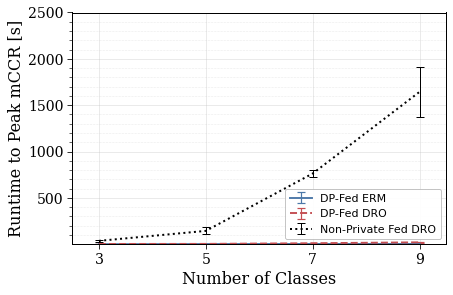

In [25]:
class_list = [3, 5, 7, 9]
seeds = [0,1, 2, 3, 4, 5, 6, 7, 8, 9]

param_dp_dro_cf = {
    "epsilon": 2e-5,
    "kappa": 0.25,
    "pnorm": float('Inf'),
    "rho": 0.5,

    "gamma_pen": 0.1,
    "tau_init": 0.0,
    "nu": None,

    "dp_on": True,
    "eps_dp": 0.1,
    "delta_dp": 1e-6,
    "cw": 1.0,
    "L": 1.0,
    "C": 0.5,

    "clambda": 1.0,
    "S_lam": 0.5,
    "V_lam": 1.0
}

param_np_dro = {
    "epsilon": 2e-5,
    "kappa": 0.25,
    "pnorm": float('Inf'),
    "rho": 0.5,
    "tau": 0,
}

param_dp_erm = {
    "rho": 0.5,
    "lambda_reg": 1e-4,
    "dp_on": True,
    "eps_dp": 0.1,
    "delta_dp": 1e-6,
    "cw": 1.0,
    "L": 1
}

FIXED_N_INFORMATIVE=10

results = run_runtime_to_peak_experiment_synth_K(
    K_LIST=class_list,
    SEEDS=seeds,
    G=4,
    NUM_ROUNDS=100,
    N_TRAIN=2400,
    N_TEST=600,
    DIM_FEATURES=15,
    PERC_WRONG_Y=0,
    FEATURE_SCALING="minmax",
    CLASS_SEP=4,
    param_np_dro=param_np_dro,
    param_dp_dro=param_dp_dro_cf,
    param_dp_erm=param_dp_erm,
    base_data_seed=777,
    tol=0.002,
    print_round_mccr=True,
    class_weights_map=None
)

plot_runtime_to_peak_vs_classes(results, use_log=False)

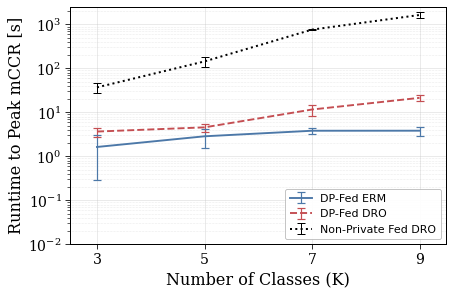

In [32]:
plot_runtime_to_peak_vs_classes(results, use_log=True)